### Task 1 — Data Exploration and Assumption Checks

In [120]:
import pandas as pd

In [121]:
import numpy as np

In [122]:
import seaborn as sns

In [123]:
from scipy.stats import t 

In [124]:
import matplotlib.pyplot as plt

In [125]:
from scipy.stats import mannwhitneyu

In [126]:
import scipy.stats as st

In [127]:
from scipy.stats import shapiro

In [128]:
from scipy.stats import levene

In [129]:
from scipy.stats import chi2_contingency, mannwhitneyu

In [130]:
df = pd.read_csv("HR-Employee-Attrition.csv")

In [131]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


1. Load the dataset and perform a quick EDA (shape, types, missing values, distributions).

In [132]:
df.shape

(1470, 35)

In [133]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [134]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [135]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [136]:
df.drop(["EmployeeCount", "EmployeeNumber", "StandardHours"], axis=1, inplace = True) 

In [137]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

My question; Why do employees left their jobs?, so my target is 'Attrition' named column. 

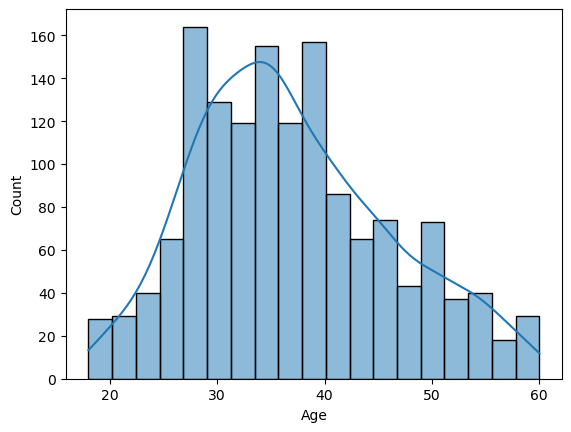

In [138]:
sns.histplot(df['Age'], kde=True)
plt.show() 

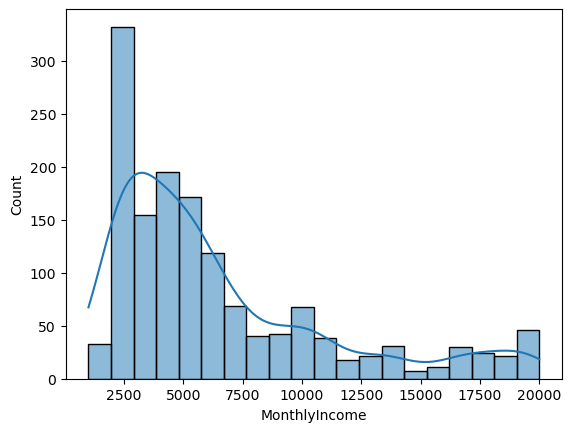

In [139]:
sns.histplot(df['MonthlyIncome'], kde=True)
plt.show()

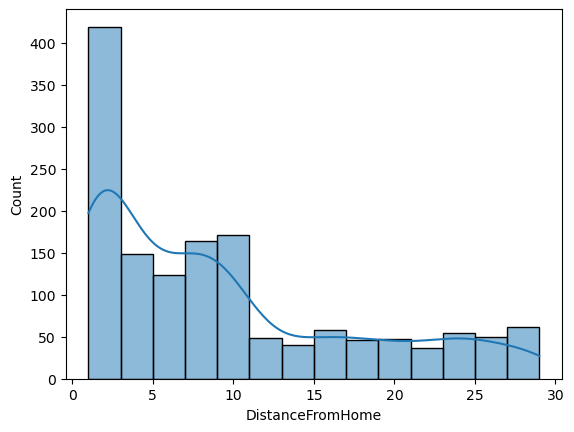

In [140]:
sns.histplot(df['DistanceFromHome'], kde=True)
plt.show()

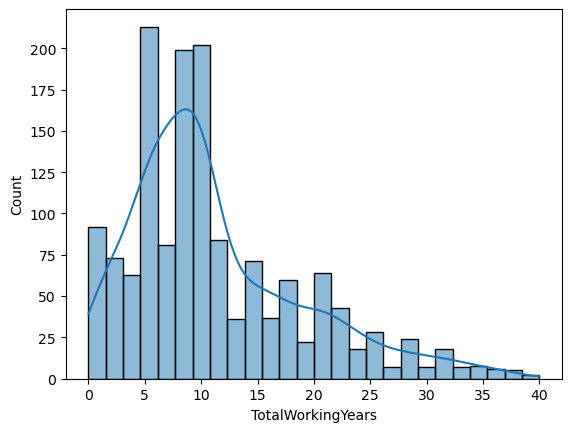

In [141]:
sns.histplot(df['TotalWorkingYears'], kde=True)
plt.show() 

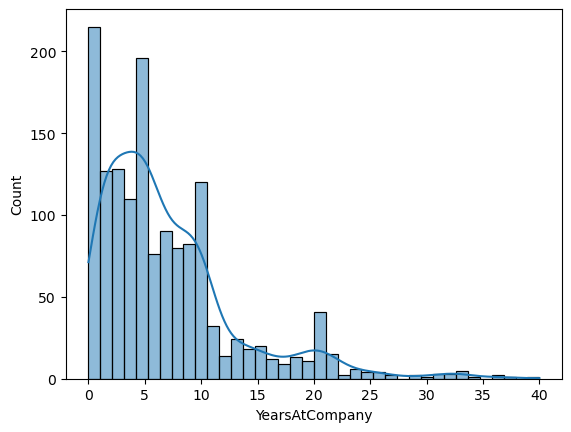

In [142]:
sns.histplot(df['YearsAtCompany'], kde=True)
plt.show()

<Axes: xlabel='YearsSinceLastPromotion', ylabel='Count'>

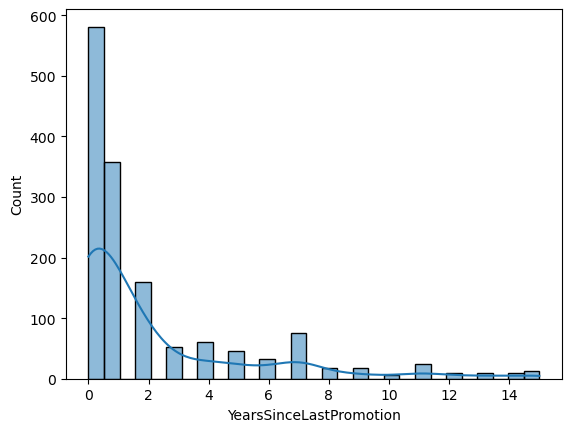

In [143]:
sns.histplot(df['YearsSinceLastPromotion'], kde = True)

<Axes: xlabel='EnvironmentSatisfaction', ylabel='Count'>

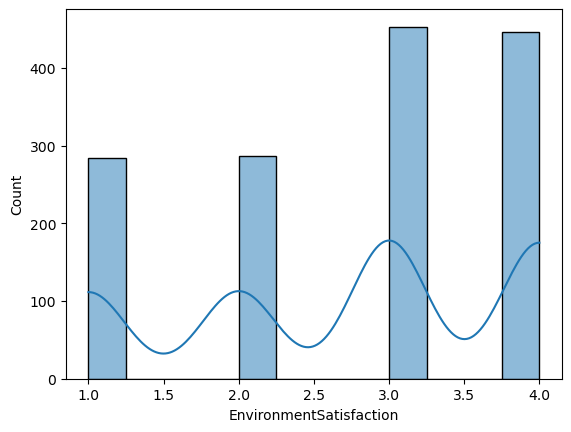

In [144]:
sns.histplot(df['EnvironmentSatisfaction'], kde=True)

<Axes: xlabel='JobSatisfaction', ylabel='Count'>

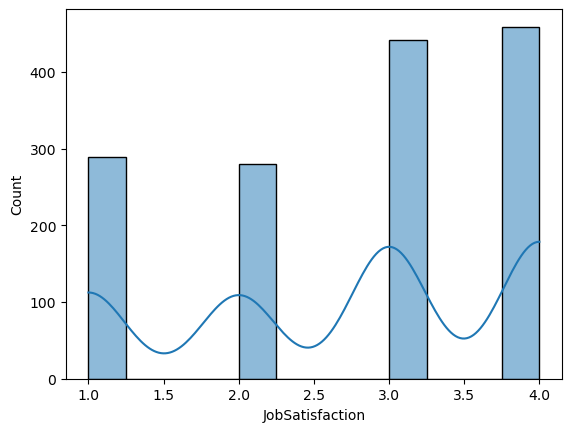

In [145]:
sns.histplot(df['JobSatisfaction'], kde = True)

<Axes: xlabel='WorkLifeBalance', ylabel='Count'>

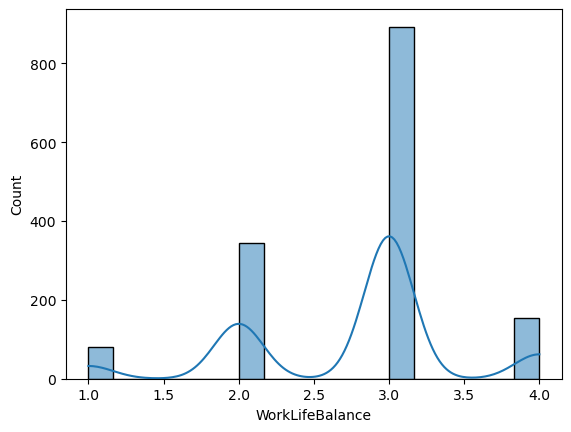

In [146]:
sns.histplot(df['WorkLifeBalance'], kde = True)

2. For each numeric variable you plan to test, check normality (Shapiro-Wilk or Q-Q plot) and equal-variance assumptions (Levene's test). 

In [147]:
# Age
# MonthlyIncome
# DistanceFromHome
# TotalWorkingYears
# YearsAtCompany
# YearsSinceLastPromotion
# WorkLifeBalance
# JobSatisfaction
# EnvironmentSatisfaction 

In [148]:
yes = df[df['Attrition'] == 'Yes']['Age']
no = df[df['Attrition'] == 'No']['Age']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no))
stat, p = levene(yes, no)
print("Levene p:", p) 

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is Ok 

Yes group: ShapiroResult(statistic=np.float64(0.9457071760167304), pvalue=np.float64(1.0051797766041198e-07))
No group: ShapiroResult(statistic=np.float64(0.9782154261921734), pvalue=np.float64(1.1064508541835448e-12))
Levene p: 0.4849988830829256


In [149]:
yes = df[df['Attrition'] == 'Yes']['MonthlyIncome']
no = df[df['Attrition'] == 'No']['MonthlyIncome']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no))
stat, p = levene(yes, no)
print("Levene p:", p)

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is not Ok, violated 

Yes group: ShapiroResult(statistic=np.float64(0.7798968527150191), pvalue=np.float64(1.5025414983521328e-17))
No group: ShapiroResult(statistic=np.float64(0.8341343315055664), pvalue=np.float64(5.9703792392981e-34))
Levene p: 0.00011830973427184532


In [150]:
yes = df[df['Attrition'] == 'Yes']['DistanceFromHome']
no = df[df['Attrition'] == 'No']['DistanceFromHome']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no))
stat, p = levene(yes, no)
print("Levene p:", p)

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is not Ok, violated 

Yes group: ShapiroResult(statistic=np.float64(0.8959438314266148), pvalue=np.float64(9.86946922339183e-12))
No group: ShapiroResult(statistic=np.float64(0.8534768459543229), pvalue=np.float64(2.4670617979829274e-32))
Levene p: 0.04808570812266364


In [151]:
yes = df[df['Attrition'] == 'Yes']['TotalWorkingYears']
no = df[df['Attrition'] == 'No']['TotalWorkingYears']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no)) 
stat, p = levene(yes, no)
print("Levene p:", p)

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is Ok

Yes group: ShapiroResult(statistic=np.float64(0.8499999812822306), pvalue=np.float64(2.0694647599549072e-14))
No group: ShapiroResult(statistic=np.float64(0.9098222064297647), pvalue=np.float64(2.095666201523993e-26))
Levene p: 0.08033291448975143


In [152]:
yes = df[df['Attrition'] == 'Yes']['YearsAtCompany']
no = df[df['Attrition'] == 'No']['YearsAtCompany']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no)) 
stat, p = levene(yes, no)
print("Levene p:", p)

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is Ok

Yes group: ShapiroResult(statistic=np.float64(0.722417815214458), pvalue=np.float64(1.2964142432923142e-19))
No group: ShapiroResult(statistic=np.float64(0.8515503368754863), pvalue=np.float64(1.6744406187525109e-32))
Levene p: 0.09726160332756505


In [153]:
yes = df[df['Attrition'] == 'Yes']['YearsSinceLastPromotion']
no = df[df['Attrition'] == 'No']['YearsSinceLastPromotion']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no)) 
stat, p = levene(yes, no)
print("Levene p:", p)

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is Ok 

Yes group: ShapiroResult(statistic=np.float64(0.660405522749705), pvalue=np.float64(1.6516689613061835e-21))
No group: ShapiroResult(statistic=np.float64(0.7110033042778257), pvalue=np.float64(1.0748292818509662e-41))
Levene p: 0.5304195027928351


In [154]:
yes = df[df['Attrition'] == 'Yes']['WorkLifeBalance']
no = df[df['Attrition'] == 'No']['WorkLifeBalance']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no)) 
stat, p = levene(yes, no)
print("Levene p:", p)

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is not Ok, violated 

Yes group: ShapiroResult(statistic=np.float64(0.8374292612824377), pvalue=np.float64(4.8434614014218545e-15))
No group: ShapiroResult(statistic=np.float64(0.7928801317021646), pvalue=np.float64(5.989667954635956e-37))
Levene p: 0.000539731518909773


In [155]:
yes = df[df['Attrition'] == 'Yes']['JobSatisfaction']
no = df[df['Attrition'] == 'No']['JobSatisfaction']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no)) 
stat, p = levene(yes, no)
print("Levene p:", p)

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is Ok 

Yes group: ShapiroResult(statistic=np.float64(0.8509285687341244), pvalue=np.float64(2.3115573961802186e-14))
No group: ShapiroResult(statistic=np.float64(0.8425372655740713), pvalue=np.float64(2.875280858621529e-33))
Levene p: 0.07248155010227386


In [156]:
yes = df[df['Attrition'] == 'Yes']['EnvironmentSatisfaction']
no = df[df['Attrition'] == 'No']['EnvironmentSatisfaction']

print("Yes group:", shapiro(yes))
print("No group:", shapiro(no)) 
stat, p = levene(yes, no)
print("Levene p:", p)

# p > 0.05 for both
# Normality is Ok
# levene p > 0.05
# Variance is not Ok, violated 

Yes group: ShapiroResult(statistic=np.float64(0.8371412623399233), pvalue=np.float64(4.689398152475652e-15))
No group: ShapiroResult(statistic=np.float64(0.8491802386693068), pvalue=np.float64(1.0451072350159869e-32))
Levene p: 0.00015239547946309747


### Task 2 — Hypothesis Test Selection and Execution 

Does working overtime influence attrition? 

In [157]:
ct = pd.crosstab(df['Attrition'], df['OverTime']) # i created a contingency table becuase i will use chi-square test

In [158]:
ct

OverTime,No,Yes
Attrition,,
No,944,289
Yes,110,127


In [159]:
chi2, p, dof, expected = chi2_contingency(ct)  
# i used chi2 becuase both two columns are categorical, with the help of this i learned that how both variables are related 

In [160]:
print(f"p={p:.6f}")

p=0.000000


In [161]:
n = ct.sum().sum() 
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n*min_dim))   
# chi2 says that there is a connection between variables or not, but what i want is how strong they are, i learned it with cramers_v

In [162]:
p  # there is not any relationship between columns; overtime and attrition. So we don't need to check the strongness of connection

np.float64(8.15842372153832e-21)

Does monthly income differ between employees who left and stayed?

In [163]:
yes_income = df[df['Attrition'] == 'Yes']['MonthlyIncome']
no_income = df[df['Attrition'] == 'No']['MonthlyIncome']

u_stat, p_val = mannwhitneyu(yes_income, no_income, alternative = 'two-sided') 
# why have i choosen Mann-Whitney U becuase it doesn't care about the shape of the data. 

In [164]:
n1 = len(yes_income)
n2 = len(no_income)
mean_u = n1*n2/2
std_u = np.sqrt(n1*n2*(n1+n2+1)/12)
z = (u_stat - mean_u)/std_u
r = z / np.sqrt(n1+n2) 

# we calculated all manually becuase mannwhitneyu doesnt returnn effect size.  

In [165]:
print(f"Overtime chi2={chi2:.4f}, p={p:.6f}, cramers_v={cramers_v:.4f}")
print(f"Income U={u_stat:.1f}, p={p_val:.6f}, r={r:.4f}")

Overtime chi2=87.5643, p=0.000000, cramers_v=0.2441
Income U=100620.5, p=0.000000, r=-0.1982


In [166]:
r 

np.float64(-0.19823751492304606)

In [167]:
# p_val < 0.05
# MonthlyIncome is significantly different between groups.\n")

Does job satisfaction influence attrition?

In [168]:
yes_js = df[df['Attrition'] == 'Yes']['JobSatisfaction']
no_js  = df[df['Attrition'] == 'No']['JobSatisfaction']

u_stat_js, p_val_js = mannwhitneyu(yes_js, no_js, alternative='two-sided') 

In [169]:
n1_js = len(yes_js)
n2_js = len(no_js)

mean_u_js = n1_js * n2_js / 2
std_u_js = np.sqrt(n1_js * n2_js * (n1_js + n2_js + 1) / 12)

In [170]:
z_js = (u_stat_js - mean_u_js) / std_u_js
r_js = z_js / np.sqrt(n1_js + n2_js)

print(u_stat_js, p_val_js, r_js)

123362.5 7.957917840891011e-05 -0.09913183094019459


In [171]:
print(f"Overtime chi2={chi2:.4f}, p={p:.6f}, cramers_v={cramers_v:.4f}") 
print(f"Income U={u_stat:.1f}, p={p_val_js:.6f}, r={r:.4f}") 

Overtime chi2=87.5643, p=0.000000, cramers_v=0.2441
Income U=100620.5, p=0.000080, r=-0.1982


In [172]:
r_js

np.float64(-0.09913183094019459)

In [173]:
# p_val_js < 0.05:
# JobSatisfaction is significantly different between groups.

### Task 3 — Confidence Intervals 

1. Compute 95% confidence intervals for at least two population parameters (e.g., a mean difference, a proportion).

In [174]:
import numpy as np
from scipy.stats import t

yes = df[df['Attrition'] == 'Yes']['MonthlyIncome']
no  = df[df['Attrition'] == 'No']['MonthlyIncome']

# a mean difference
mean_yes = np.mean(yes)
mean_no = np.mean(no)

# Standard errors
se_yes = np.std(yes, ddof=1) / np.sqrt(len(yes))
se_no = np.std(no, ddof=1) / np.sqrt(len(no))

# Degrees of freedom
df_yes = len(yes) - 1
df_no = len(no) - 1

# t critical
t_yes = t.ppf(0.975, df_yes)
t_no = t.ppf(0.975, df_no) 

lower = diff - t_yes * se
upper = diff + t_no * se

print("Mean difference:", diff)
print("95% CI:", (lower, upper)) 

Mean difference: -2045.646832363177
95% CI: (np.float64(-2584.2362787121683), np.float64(-1509.2924461966911))


In [175]:
from statsmodels.stats.proportion import proportion_confint

# a proportion 

count = len(df[(df['Attrition']=='Yes') & (df['OverTime']=='Yes')])

nobs = len(df[df['OverTime']=='Yes'])

lower, upper = proportion_confint(count, nobs, alpha=0.05, method='normal')

print("Proportion:", count/nobs) 
print("95% CI:", (lower, upper)) 

Proportion: 0.30528846153846156
95% CI: (0.2610338149444763, 0.3495431081324468)


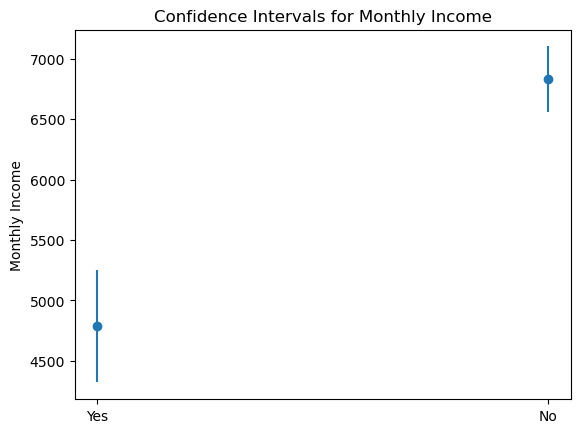

In [176]:
import matplotlib.pyplot as plt

err_yes = t_yes * se_yes
err_no = t_no * se_no

# Plot
means = [mean_yes, mean_no]
errors = [err_yes, err_no]

labels = ['Yes', 'No']

plt.errorbar(labels, means, yerr=errors, fmt='o')
plt.title("Confidence Intervals for Monthly Income")
plt.ylabel("Monthly Income")
plt.show()

##### Yes → employees who left
##### No → employees who stayed
##### Each point = average income
##### Each vertical line = 95% confidence interval (CI)
##### Yes (left) → around 4800
##### No (stayed) → around 6800

##### Confidence intervals (the lines)
##### “Yes” group CI → roughly 4300 to 5200
##### “No” group CI → roughly 6600 to 7100

##### Employees with lower salaries are more likely to leave

### Task 4 — Power Analysis 

In [177]:
from statsmodels.stats.power import TTestIndPower

n1 = len(yes_income)
n2 = len(no_income)

r = r  

d = 2*r / np.sqrt(1 - r**2) 

analysis = TTestIndPower()

power = analysis.power(effect_size=d, nobs1=n1, ratio=n2/n1, alpha=0.05)

print("Effect size (d):", d)
print("Power:", power) 

Effect size (d): -0.4045027872169013
Power: 0.9999078070928153


In [178]:
sample_size = analysis.solve_power(effect_size=d, power=0.8, alpha=0.05)

print("Required sample size per group:", sample_size) 

Required sample size per group: 96.90841978604323


### Task 5 — Executive Summary  

I have chosen an HR dataset and aimed to examine whether different features influence employees’ decisions to leave the company. The main focus of the analysis is the ‘Attrition’ column, which indicates whether an employee has left or stayed. By exploring the dataset, I focused on variables such as Age, MonthlyIncome, DistanceFromHome, TotalWorkingYears, YearsAtCompany, YearsSinceLastPromotion, WorkLifeBalance, JobSatisfaction, and EnvironmentSatisfaction, as these factors may help explain employee turnover.

To better understand the dataset, several research questions were developed. One of the questions was “Does working overtime influence attrition?”. The results show that working overtime is not significantly associated with employee turnover, as the statistical test did not provide sufficient evidence of a relationship. This suggests that overtime alone may not be a key factor influencing employees’ decisions to leave the company.

Another important question was “Does monthly income differ between employees who left and those who stayed?”. The analysis indicates that monthly income plays a meaningful role in employee retention. Employees who left the company tend to have lower income levels compared to those who stayed. This suggests that compensation may not be competitive enough for some employees, which could encourage them to seek better opportunities elsewhere.

A third question explored was “Does job satisfaction influence attrition?”. The results show that employees with lower job satisfaction levels are more likely to leave the company. This highlights the importance of maintaining a positive work environment, strong management practices, and high levels of employee engagement in order to retain staff.

To ensure the reliability of these findings, statistical methods were applied to evaluate the strength and consistency of the results. Confidence intervals were also calculated to estimate the range within which the true values are likely to fall. These intervals support the findings by showing that the observed differences are not only visible in the sample but are likely to exist in the broader population as well.

However, some limitations should be considered. The analysis is based on historical data, which means it can identify relationships but cannot confirm cause-and-effect. Additionally, some potentially important factors—such as organizational culture or external job opportunities—are not included in the dataset.

Based on the findings, several recommendations can be made. The company should review its compensation policies to ensure salaries are competitive. It should also invest in improving job satisfaction through employee engagement initiatives, career development programs, and better management practices. Addressing these areas can help reduce employee turnover and improve overall organizational stability.